In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.image import resize
import matplotlib.pyplot as plt

import librosa

data_folder = "../Data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

In [2]:
def preprocessing_wav_to_melspectogram(data_folder, classes, target_shape = (150,150), chunk_duration = 4, overlap_duration = 2):
    melspectograms_list = []
    labels_list = []
    for class_number, class_name in enumerate(classes):
        class_folder = os.path.join(data_folder, class_name)
        print(f'Processing of class {class_name} data is ongoing')
        for filename in os.listdir(class_folder):
            if filename.endswith('.wav'):
                file_path = os.path.join(class_folder, filename)
                audio_data, sample_rate = librosa.load(file_path, sr = None)
                chunk_samples = int(sample_rate * chunk_duration)
                overlap_samples = int(sample_rate * overlap_duration)

                num_of_chunks = int(np.ceil((len(audio_data) - chunk_samples) /(chunk_samples -  overlap_samples)))+1

                for i in range(num_of_chunks):
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples

                    chunk = audio_data[start:end]

                    mel_spectogram = librosa.feature.melspectrogram(y = chunk, sr = sample_rate)

                    mel_spectogram = resize(np.expand_dims(mel_spectogram, axis = -1),target_shape)

                    melspectograms_list.append(mel_spectogram)
                    labels_list.append(class_number)
    return np.array(melspectograms_list), np.array(labels_list)





In [3]:
data, labels = preprocessing_wav_to_melspectogram(data_folder, classes)

Processing of class blues data is ongoing
Processing of class classical data is ongoing
Processing of class country data is ongoing
Processing of class disco data is ongoing
Processing of class hiphop data is ongoing
Processing of class jazz data is ongoing
Processing of class metal data is ongoing
Processing of class pop data is ongoing
Processing of class reggae data is ongoing
Processing of class rock data is ongoing


In [4]:
print(data.shape)

(14975, 150, 150, 1)


In [5]:
print(labels.shape)

(14975,)


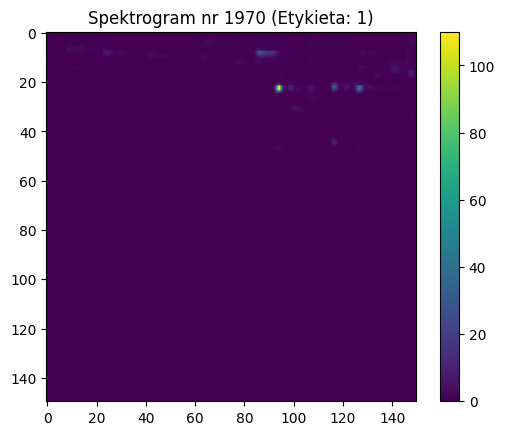

In [6]:
example_number = 1970
example_melspectogram_x = data[example_number]
example_melspectogram_y = labels[example_number]
plt.imshow(example_melspectogram_x.squeeze())
plt.title(f"Spektrogram nr {example_number} (Etykieta: {example_melspectogram_y})")
plt.colorbar()
plt.show()

In [7]:
from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels,num_classes = len(classes))
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(14975, 10))

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(data,labels,test_size=0.2,random_state=42)

In [9]:
model = tf.keras.models.Sequential()

In [10]:
X_train[0].shape

(150, 150, 1)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=X_train[0].shape))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Flatten())

model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=len(classes), activation='softmax'))

C:\Users\matis\OneDrive\Pulpit\Studio_projektowe\GenreAI\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,712,330 (40.86 MB)

 Trainable params: 10,712,330 (40.86 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
training_history = model.fit(X_train,Y_train,epochs=30,batch_size=32,validation_data=(X_test,Y_test))

Epoch 1/30
 53/375 ━━━━━━━━━━━━━━━━━━━━ 3:19 620ms/step - accuracy: 0.1374 - loss: 11.9790